# Scheme B: Model outputs scalar estimating the number of components (K)



In [3]:

### imports
import math
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

def set_cpu_safety(num_threads: int = 1):
    """Helps avoid CPU oversubscription / kernel death in notebooks."""
    torch.set_num_threads(num_threads)
    torch.set_num_interop_threads(num_threads)

def deep_update(base: dict, updates: dict) -> dict:
    """Recursively update dicts (for cfg overrides). Does not mutate inputs."""
    out = deepcopy(base)
    for k, v in updates.items():
        if isinstance(v, dict) and isinstance(out.get(k, None), dict):
            out[k] = deep_update(out[k], v)
        else:
            out[k] = deepcopy(v)
    return out


In [5]:

### synthetic spectrum generator

DEFAULT_GEN = dict(
    ### K distribution:
    p_zero=0.0,
    k_mean=3.0,
    k_tail_prob=0.50,
    k_tail_min=6,  

    ### Component priors:
    amp_lognorm_mu=0.0,
    amp_lognorm_sigma=1.0,
    sigma_min=0.1,
    sigma_max=10.0,

    ### Optional blending:
    blend_cluster_prob=0.0,
    cluster_width_range=(1.0, 30.0),

    ### Baseline/noise:
    noise_std_range=(0.02, 0.15),
    baseline_poly_prob=0.5,
    baseline_max_slope=0.02,
    baseline_max_quad=0.0002,
)

def _make_v_axis(cfg: dict) -> np.ndarray:
    vmin, vmax = cfg["vrange"]
    C = int(cfg["n_channels"])
    return np.linspace(vmin, vmax, C, dtype=np.float32)

def generate_spectrum(cfg: dict, rng: np.random.Generator, v_axis: np.ndarray | None = None) -> dict[str, np.ndarray]:
    """
    Returns:
      spec       : noisy spectrum, (C,)
      spec_clean : pure Gaussian spectrum (no baseline/noise), (C,)
      k          : true latent number of Gaussians (int)
      noise_std  : (1,)
    """
    vmin, vmax = cfg["vrange"]
    C = int(cfg["n_channels"])
    Kmax = int(cfg["max_components"])
    min_components = int(cfg.get("min_components", 0))

    gen = deep_update(DEFAULT_GEN, cfg.get("gen", {}))
    k_tail_max = min(10, Kmax)
    v = v_axis if v_axis is not None else _make_v_axis(cfg)

    ### sample k
    if rng.random() < gen["p_zero"]:
        k = 0
    else:
        if rng.random() < gen["k_tail_prob"]:
            k = int(rng.integers(gen["k_tail_min"], k_tail_max + 1))
        else:
            k = max(1, int(rng.poisson(gen["k_mean"])))
        k = max(k, min_components) if k > 0 else 0
        k = min(k, Kmax)

    ### sample params (kept internal; Scheme B doesn't use them)
    A = np.zeros(Kmax, dtype=np.float32)
    mu = np.zeros(Kmax, dtype=np.float32)
    sig = np.ones(Kmax, dtype=np.float32)

    if k > 0:
        ### centers
        if rng.random() < gen["blend_cluster_prob"] and k >= 2:
            center = rng.uniform(vmin + 0.2*(vmax - vmin), vmax - 0.2*(vmax - vmin))
            cw = rng.uniform(*gen["cluster_width_range"])
            mus = center + rng.normal(0.0, cw, size=k)
            mus = np.clip(mus, vmin, vmax)
        else:
            mus = rng.uniform(vmin, vmax, size=k)

        ### widths + amps
        sigs = rng.uniform(gen["sigma_min"], gen["sigma_max"], size=k)
        amps = rng.lognormal(mean=gen["amp_lognorm_mu"], sigma=gen["amp_lognorm_sigma"], size=k)
        amps = amps / (np.percentile(amps, 90) + 1e-6)

        ### sort by centroid
        order = np.argsort(mus)
        mus, sigs, amps = mus[order], sigs[order], amps[order]

        A[:k] = amps.astype(np.float32)
        mu[:k] = mus.astype(np.float32)
        sig[:k] = sigs.astype(np.float32)

    ### build clean
    spec = np.zeros(C, dtype=np.float32)
    for i in range(k):
        dv = (v - mu[i]) / (sig[i] + 1e-6)
        spec += A[i] * np.exp(-0.5 * dv * dv).astype(np.float32)
    spec_clean = spec.copy()

    ### baseline
    if rng.random() < gen["baseline_poly_prob"]:
        x = np.linspace(-1, 1, C, dtype=np.float32)
        slope = rng.uniform(-gen["baseline_max_slope"], gen["baseline_max_slope"])
        quad = rng.uniform(-gen["baseline_max_quad"], gen["baseline_max_quad"])
        spec += (slope * x + quad * (x**2)).astype(np.float32)

    ### noise
    noise_std = float(rng.uniform(*gen["noise_std_range"]))
    spec += rng.normal(0.0, noise_std, size=C).astype(np.float32)

    return dict(
        spec=spec,
        spec_clean=spec_clean,
        k=int(k),
        noise_std=np.array([noise_std], dtype=np.float32),
    )


In [6]:

### dataset + loaders (Scheme B: returns only spec and K_true; keeps spec_clean for plots)

class SyntheticSpectraDataset(Dataset):
    def __init__(self, cfg: dict, n_samples: int, base_seed: int = 0):
        self.cfg = cfg
        self.v_axis = _make_v_axis(cfg)
        self.n_samples = int(n_samples)
        self.base_seed = int(base_seed)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx: int):
        rng = np.random.default_rng(self.base_seed + int(idx))
        ex = generate_spectrum(self.cfg, rng=rng, v_axis=self.v_axis)

        K_true = np.array([ex["k"]], dtype=np.int64)  # (1,)

        return {
            "spec": torch.from_numpy(ex["spec"]).float(),               # (C,)
            "spec_clean": torch.from_numpy(ex["spec_clean"]).float(),   # (C,)
            "K_true": torch.from_numpy(K_true).long(),                  # (1,)
        }

BASE_CFG = dict(
    n_channels=256,
    min_components=0,
    max_components=10,
    vrange=(-200.0, 200.0),
    gen=deepcopy(DEFAULT_GEN),
)

def make_loaders(cfg: dict, *, n_train=50_000, n_val=5_000, bs_train=128, bs_val=256):
    train_ds = SyntheticSpectraDataset(cfg, n_samples=n_train, base_seed=0)
    val_ds   = SyntheticSpectraDataset(cfg, n_samples=n_val, base_seed=10_000_000)

    train_loader = DataLoader(train_ds, batch_size=bs_train, shuffle=True, num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=bs_val,   shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader


In [7]:
@torch.no_grad()
def plot_example(ds: Dataset, idx: int = 0, title: str = ""):
    ex = ds[idx]
    v = ds.v_axis
    plt.figure(figsize=(10, 3))
    plt.plot(v, ex["spec"].numpy(), label="spec (noisy)", lw=1.8, alpha=0.8)
    plt.plot(v, ex["spec_clean"].numpy(), label="spec_clean", lw=1.8, alpha=0.8)
    k = int(ex["K_true"].item())
    plt.title(title or f"Example idx={idx}  K_true={k}")
    plt.xlabel("Velocity (km/s)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

In [9]:
### The model du jour: tiny 1D CNN encoder + global average pooling + linear head.

class CountNet1D(nn.Module):
    def __init__(self, width=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
        )
        self.head = nn.Linear(width, 1)

    def forward(self, x):
        # x: (B = batch size, C = num vel channels)
        h = self.conv(x.unsqueeze(1))      # (B, width, C)
        h = h.mean(dim=-1)                 # (B, width)
        y = self.head(h).squeeze(-1)       # (B,)
        return y


In [10]:
### training loop with Huber loss

def train_count(model, train_loader, val_loader, device="cpu", lr=1e-3, epochs=3, log_every=200, Kmax=10):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for ep in range(1, epochs+1):
        model.train()
        running = 0.0

        for step, batch in enumerate(train_loader, start=1):
            x = batch["spec"].to(device)                         # (B,C)

            ### per-spectrum normalization
            x = x - x.mean(dim=1, keepdim=True)
            x = x / (x.std(dim=1, keepdim=True) + 1e-6)

            K = batch["K_true"].to(device).float().squeeze(-1)   # (B,)
            K_hat = model(x)                                     # (B,)

            loss = loss_fn(K_hat, K)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            running += loss.item()
            if step % log_every == 0:
                print(f"epoch {ep} step {step} train_loss {running/log_every:.4f}")
                running = 0.0

        ### validation: MAE on rounded K
        model.eval()
        mae = 0.0
        n = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch["spec"].to(device)
                x = x - x.mean(dim=1, keepdim=True)
                x = x / (x.std(dim=1, keepdim=True) + 1e-6)

                K = batch["K_true"].to(device).long().squeeze(-1)
                K_hat = model(x)
                K_pred = torch.clamp(torch.round(K_hat), 0, Kmax).long()

                mae += (K_pred - K).abs().sum().item()
                n += x.size(0)

        print(f"epoch {ep} val_K_MAE {mae/n:.3f}")

    return model


In [11]:
### actually running it! (a lot of this is so my laptop does not crash??)

set_cpu_safety(1)

cfg = deep_update(BASE_CFG, {})
train_loader, val_loader = make_loaders(cfg)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CountNet1D(width=64)

Kmax = cfg["max_components"]
model = train_count(model, train_loader, val_loader, device=device, lr=1e-3, epochs=3, log_every=200, Kmax=Kmax)


epoch 1 step 200 train_loss 1.6376
epoch 1 val_K_MAE 1.565
epoch 2 step 200 train_loss 1.1357
epoch 2 val_K_MAE 1.427
epoch 3 step 200 train_loss 1.0148
epoch 3 val_K_MAE 1.344


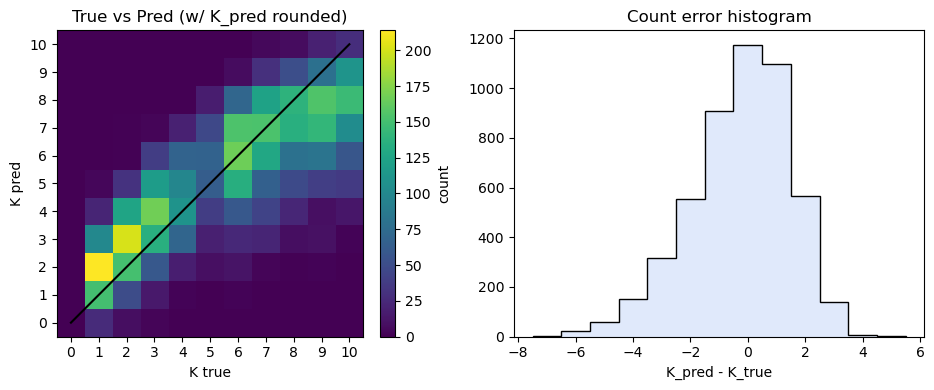

In [12]:
#### visualizing

@torch.no_grad()
def collect_count_predictions(model, loader, device="cpu", Kmax=10, max_batches=50):
    model.eval()
    y_true = []
    y_pred = []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        x = batch["spec"].to(device)
        x = x - x.mean(dim=1, keepdim=True)
        x = x / (x.std(dim=1, keepdim=True) + 1e-6)

        K = batch["K_true"].to(device).long().squeeze(-1)
        K_hat = model(x)
        Kp = torch.clamp(torch.round(K_hat), 0, Kmax).long()

        y_true.append(K.cpu().numpy())
        y_pred.append(Kp.cpu().numpy())

    return np.concatenate(y_true), np.concatenate(y_pred)

y_true, y_pred = collect_count_predictions(model, val_loader, device=device, Kmax=Kmax, max_batches=50)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))



# true vs pred
# true vs pred (2D histogram instead of scatter)
edges = np.arange(-0.5, Kmax + 1.5, 1.0)  # integer-centered bins: 0..Kmax
H, xedges, yedges = np.histogram2d(y_true, y_pred, bins=[edges, edges])

im = axes[0].imshow(
    H.T,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
)

axes[0].plot([0, Kmax], [0, Kmax], lw=1.5, color="k")
axes[0].set_xlabel("K true")
axes[0].set_ylabel("K pred")
axes[0].set_title("True vs Pred (w/ K_pred rounded)")

ticks = np.arange(0, Kmax + 1, 1)
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)

# colorbar for the left panel
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="count")

# error histogram
err = (y_pred - y_true)
axes[1].hist(err, bins=np.arange(err.min()-0.5, err.max()+1.5, 1), color='cornflowerblue', alpha=0.2)
axes[1].hist(err, bins=np.arange(err.min()-0.5, err.max()+1.5, 1),histtype='step',color='k',lw=1)

axes[1].set_xlabel("K_pred - K_true")
axes[1].set_title("Count error histogram")

plt.tight_layout()
plt.show()
plt.close(fig)


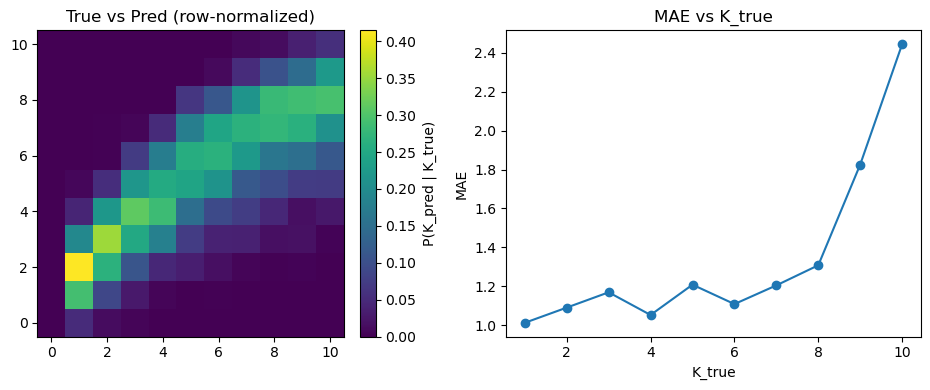

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

### Row-normalized 2D histogram
Hn = H / (H.sum(axis=1, keepdims=True) + 1e-12)

im = axes[0].imshow(
    Hn.T,
    origin="lower",
    aspect="equal",
    interpolation="nearest",
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
)
axes[0].set_title("True vs Pred (row-normalized)")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="P(K_pred | K_true)")

### MAE vs K_true
mae_by_k = []
ks = np.arange(0, Kmax + 1)
for k in ks:
    m = (y_true == k)
    mae_by_k.append(np.mean(np.abs(y_pred[m] - y_true[m])) if np.any(m) else np.nan)

axes[1].plot(ks, mae_by_k, marker="o")
axes[1].set_xlabel("K_true")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE vs K_true")
plt.tight_layout()
plt.show()
